## LIME for time series

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = Path("out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def data_path(filename):
    return DATA_DIR / filename

def out_path(filename):
    return OUT_DIR / filename


In [1]:
! pip install ruptures
! pip install datasets

In [2]:
#@title Python library imports go here
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import ruptures as rpt
from datasets import load_dataset
import os
import torch
import numpy as np
from sklearn.linear_model import Ridge

from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm

In [3]:
class ECG200Dataset(Dataset):
    def __init__(self, file_path):
        # Load data: first column is label (-1 or 1), rest are signal values
        data = np.loadtxt(file_path)
        labels = data[:, 0]
        signals = data[:, 1:]
        # Map labels to 0 and 1 for PyTorch
        labels = np.where(labels == -1.0, 0, 1)
        self.signals = torch.tensor(signals, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Return a single sample (signal, label)
        return self.signals[idx], self.labels[idx]


class InceptionBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=(10, 20, 40), bottleneck_channels=32, use_bottleneck=True, dropout=0.2):
        super(InceptionBlock, self).__init__()
        self.use_bottleneck = use_bottleneck and in_channels > 1
        if self.use_bottleneck:
            self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        conv_in = bottleneck_channels if self.use_bottleneck else in_channels

        # Multi-scale convolution branches with padding='same' to preserve length
        self.branch_convs = nn.ModuleList([
            nn.Conv1d(conv_in, out_channels, kernel_size=k, padding='same', bias=False)
            for k in kernel_sizes
        ])
        # Pooling branch also preserves length
        self.branch_pool = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        self.batchnorm = nn.BatchNorm1d(out_channels * (len(kernel_sizes) + 1))
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        inp = x
        if self.use_bottleneck:
            x = self.bottleneck(x)
        branches = [self.dropout(self.activation(conv(x))) for conv in self.branch_convs]
        pool = self.branch_pool(inp)
        branches.append(self.dropout(self.activation(pool)))
        out = torch.cat(branches, dim=1)
        out = self.batchnorm(out)
        return out


class InceptionResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(InceptionResNetBlock, self).__init__()
        self.inception = InceptionBlock(in_channels, out_channels, **kwargs)
        total_channels = out_channels * (len(kwargs.get('kernel_sizes', (10,20,40))) + 1)
        self.residual_conv = (
            nn.Conv1d(in_channels, total_channels, kernel_size=1, bias=False)
            if in_channels != total_channels
            else None
        )
        self.bn = nn.BatchNorm1d(total_channels)
        self.activation = nn.ReLU()

    def forward(self, x):
        z = self.inception(x)
        res = x if self.residual_conv is None else self.residual_conv(x)
        z = z + res
        z = self.bn(z)
        return self.activation(z)


class InceptionTime(nn.Module):
    def __init__(self, num_blocks=3, in_channels=1, out_channels=32, num_classes=2,
                 kernel_sizes=(10,20,40), bottleneck_channels=32, dropout=0.2):
        super(InceptionTime, self).__init__()
        blocks = []
        channels = in_channels
        for _ in range(num_blocks):
            blocks.append(
                InceptionResNetBlock(
                    in_channels=channels,
                    out_channels=out_channels,
                    kernel_sizes=kernel_sizes,
                    bottleneck_channels=bottleneck_channels,
                    dropout=dropout,
                    use_bottleneck=True
                )
            )
            channels = out_channels * (len(kernel_sizes) + 1)
        self.features = nn.Sequential(*blocks)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(channels, num_classes)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        x = self.features(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)


# Create datasets and loaders
train_dataset = ECG200Dataset(data_path("ECG200_TRAIN.txt"))
test_dataset = ECG200Dataset(data_path("ECG200_TEST.txt"))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize model, loss, optimizer, scheduler
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = InceptionTime(num_blocks=3, in_channels=1, out_channels=32, num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

# Training and validation loop
EPOCHS = 42 + 1
for epoch in range(1, EPOCHS):
    model.train()
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for signals, labels in test_loader:
            signals, labels = signals.to(device), labels.to(device)
            outputs = model(signals)
            val_loss += criterion(outputs, labels).item() * signals.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= total
    val_acc = correct / total
    print(f'Epoch {epoch:03d} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
    scheduler.step(val_loss)

torch.save(model.state_dict(), data_path("inception_time_ecg200.pth"))

/Users/juliawenkmann/miniconda3/envs/ml/lib/python3.11/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1037.)
  return F.conv1d(


Epoch 001 | Val Loss: 0.6398 | Val Acc: 0.6400
Epoch 002 | Val Loss: 0.6330 | Val Acc: 0.6400
Epoch 003 | Val Loss: 0.6497 | Val Acc: 0.6400
Epoch 004 | Val Loss: 0.6618 | Val Acc: 0.7900
Epoch 005 | Val Loss: 0.6284 | Val Acc: 0.7500
Epoch 006 | Val Loss: 0.5870 | Val Acc: 0.7700
Epoch 007 | Val Loss: 0.5370 | Val Acc: 0.7900
Epoch 008 | Val Loss: 0.5270 | Val Acc: 0.8200
Epoch 009 | Val Loss: 0.5291 | Val Acc: 0.8200
Epoch 010 | Val Loss: 0.3929 | Val Acc: 0.8300
Epoch 011 | Val Loss: 0.4214 | Val Acc: 0.7600
Epoch 012 | Val Loss: 0.3589 | Val Acc: 0.8400
Epoch 013 | Val Loss: 0.3660 | Val Acc: 0.8100
Epoch 014 | Val Loss: 0.3532 | Val Acc: 0.8500
Epoch 015 | Val Loss: 0.3650 | Val Acc: 0.8500
Epoch 016 | Val Loss: 0.4089 | Val Acc: 0.8300
Epoch 017 | Val Loss: 0.4034 | Val Acc: 0.8200
Epoch 018 | Val Loss: 0.3297 | Val Acc: 0.8400
Epoch 019 | Val Loss: 0.3655 | Val Acc: 0.8600
Epoch 020 | Val Loss: 0.3064 | Val Acc: 0.8200
Epoch 021 | Val Loss: 0.3165 | Val Acc: 0.8700
Epoch 022 | V

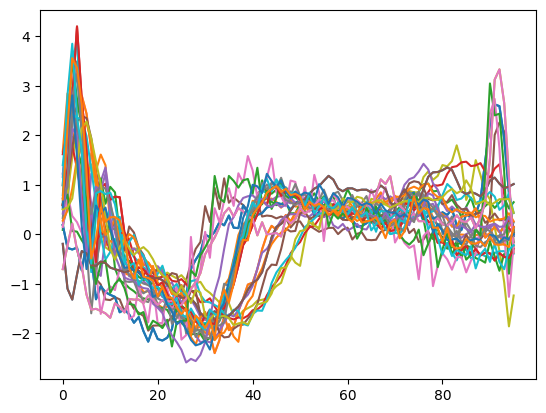

In [4]:
for i in range(32):
  sample = next(iter(train_loader))[0][i].numpy()

  plt.plot(sample)

## Chnage Point Detection

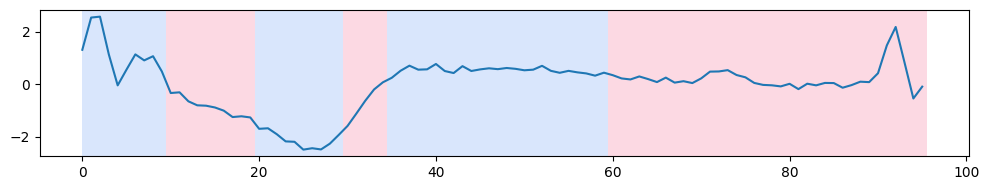

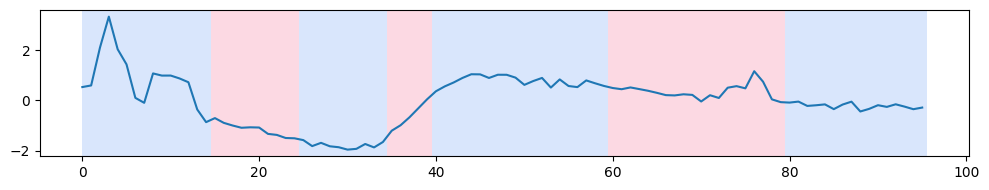

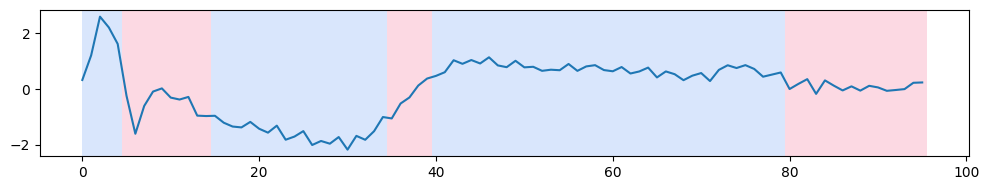

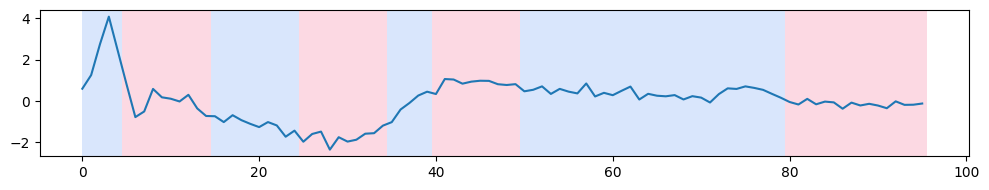

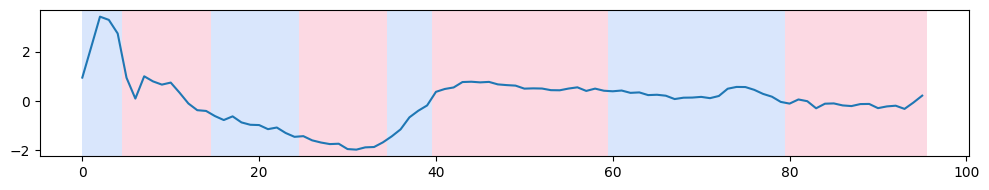

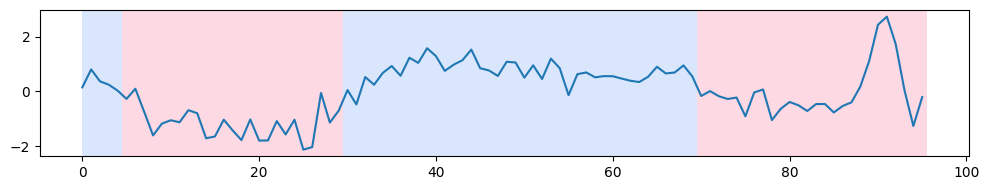

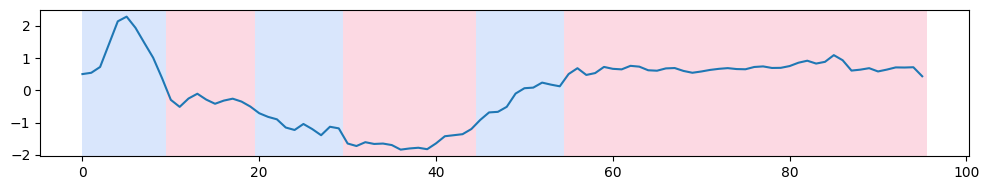

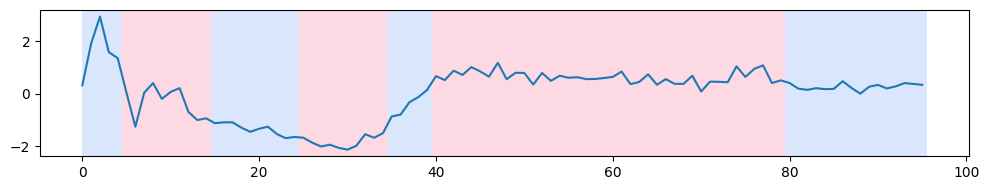

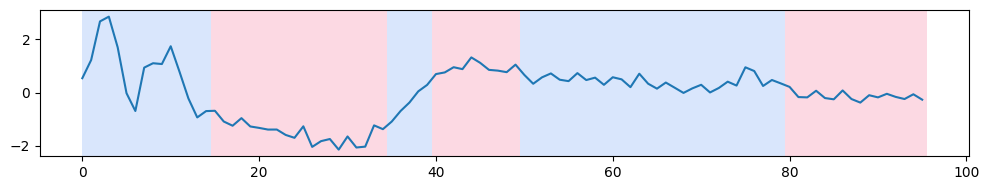

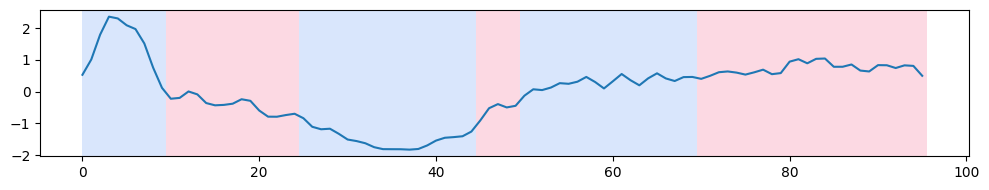

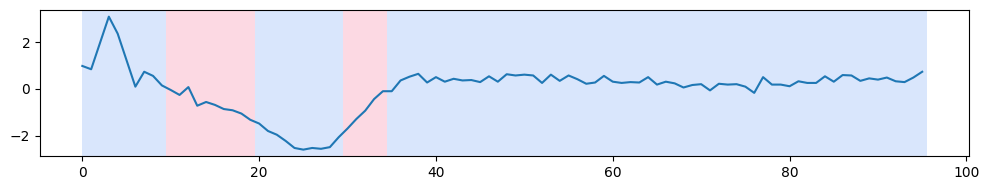

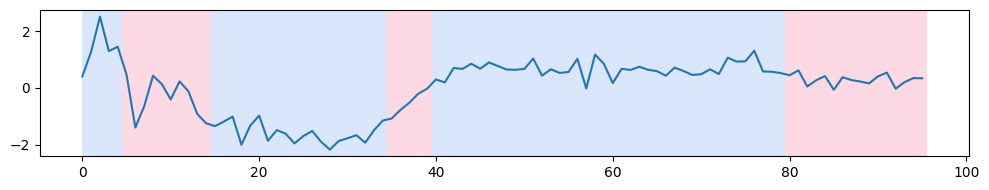

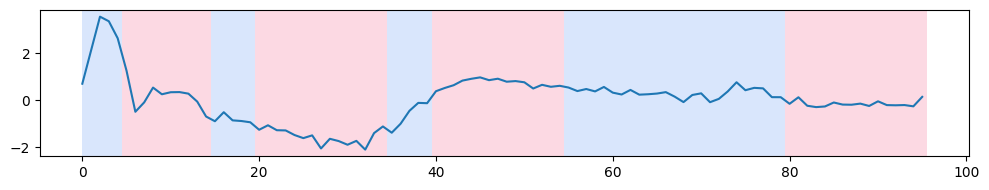

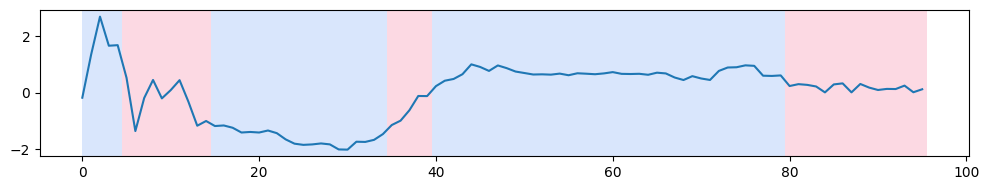

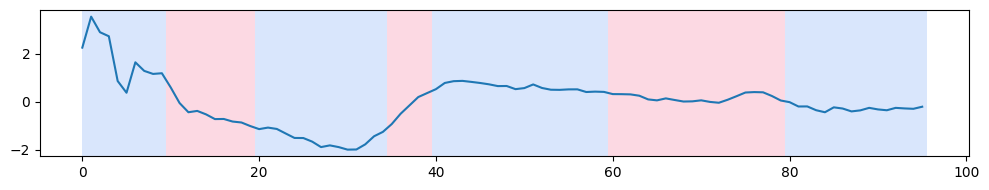

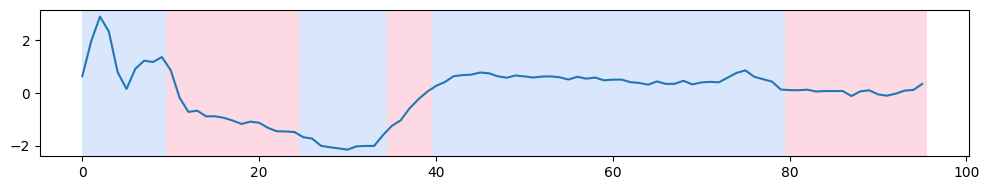

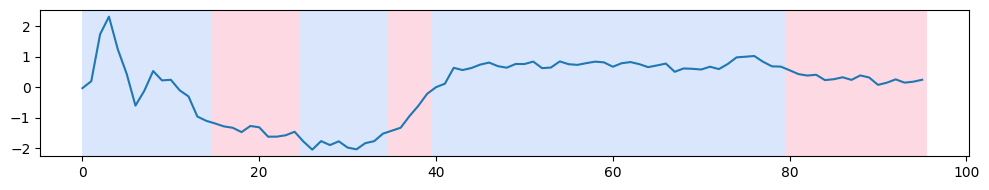

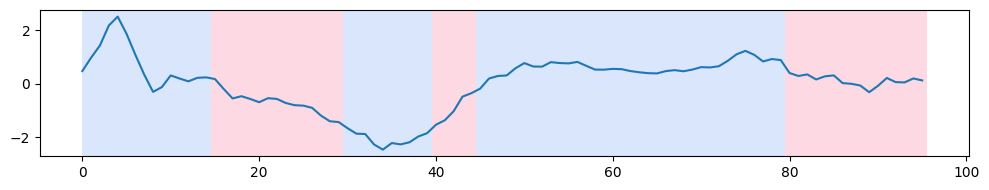

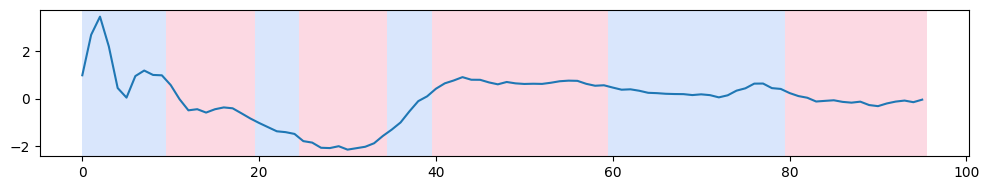

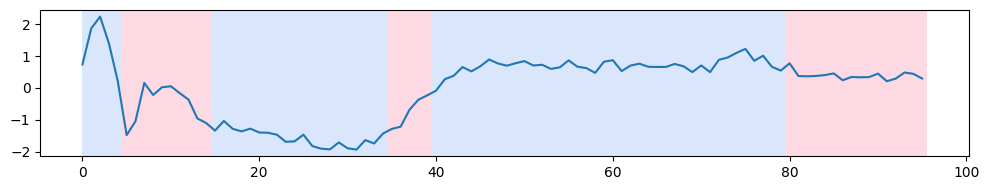

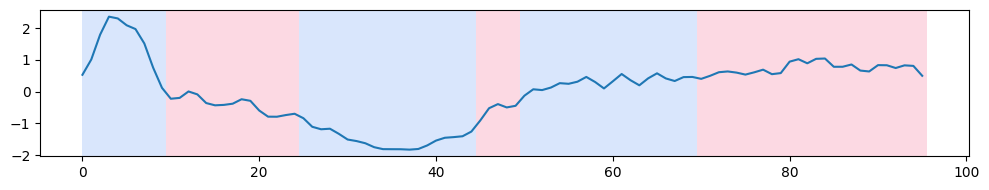

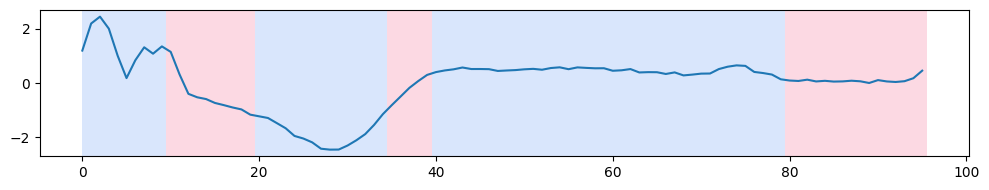

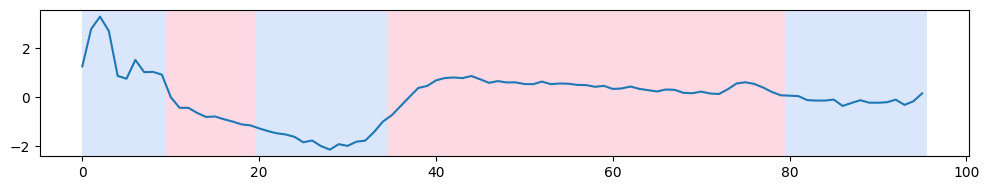

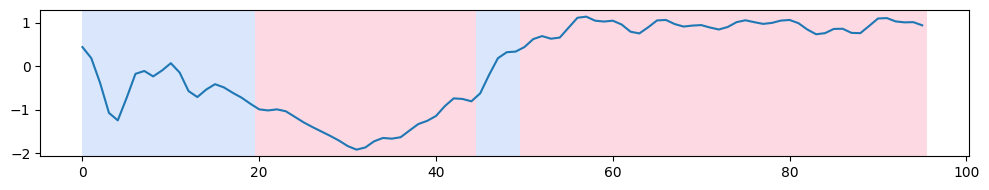

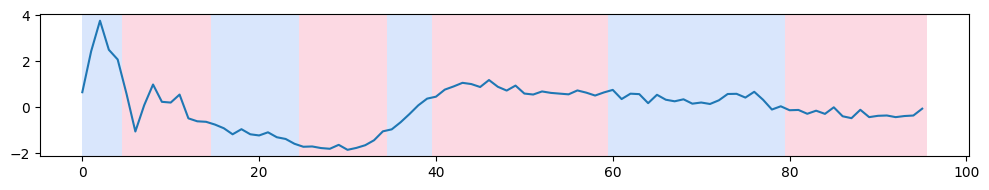

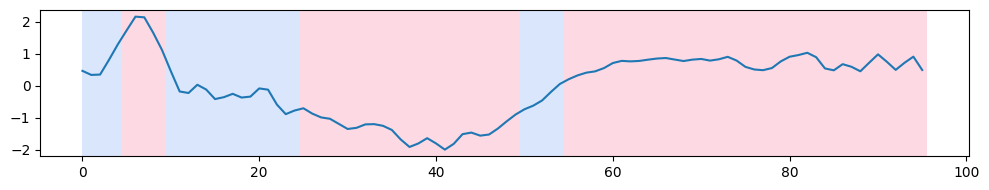

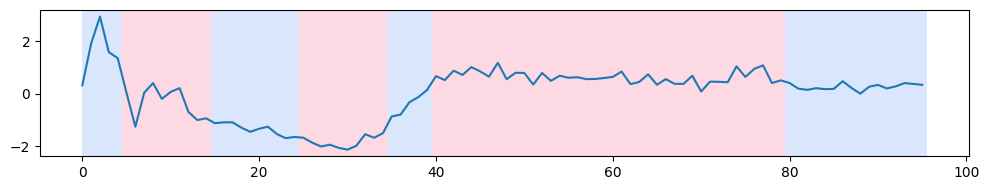

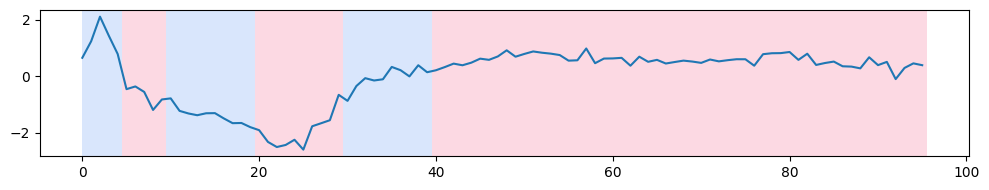

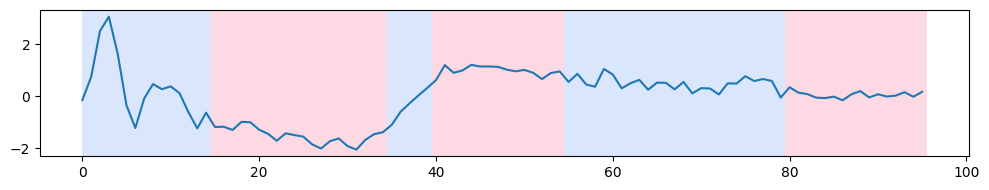

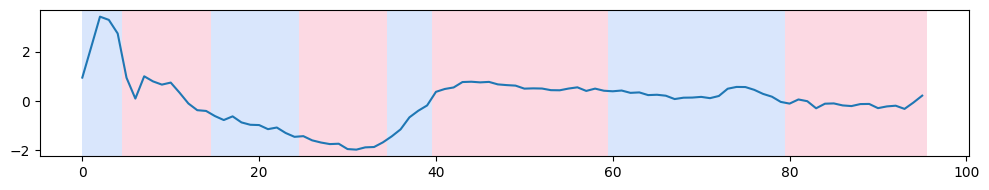

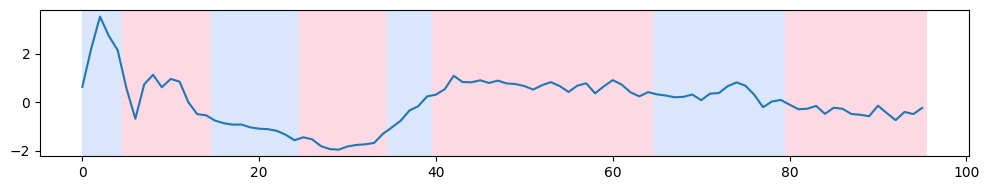

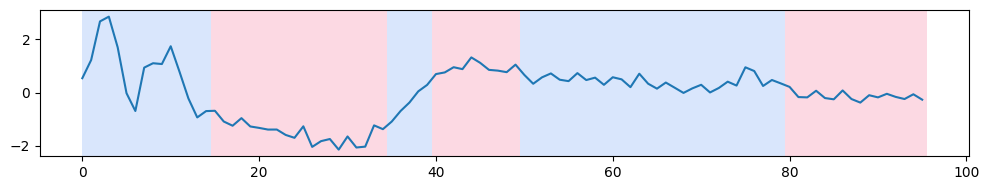

In [5]:
for i in range(32):
  sample = next(iter(train_loader))[0][i].numpy()
  # detection
  algo = rpt.Pelt(model="rbf").fit(sample)
  result = algo.predict(pen=2)

  # display
  rpt.display(sample, result)
  plt.show()

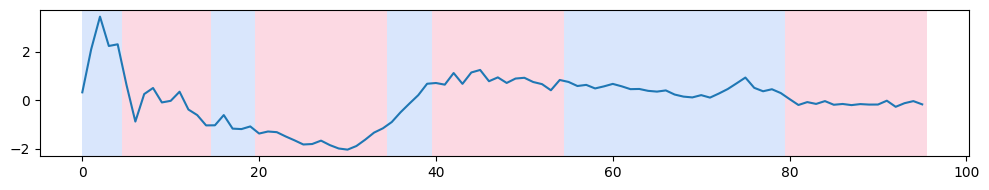

In [6]:
sample = next(iter(train_loader))[0][0].numpy()
# detection
algo = rpt.Pelt(model="rbf").fit(sample)
result = algo.predict(pen=2)
# display
rpt.display(sample, result)
plt.show()

In [7]:
result

[5, 15, 20, 35, 40, 55, 80, 96]

## Perturbation with STFT

In [8]:
i = 3
segment = torch.tensor(sample[result[i]:result[i+1]])

In [9]:
def compute_stft(signal, n_fft=64, hop_length=32):
    if signal.dim() == 2 and signal.size(0) == 1:
        signal = signal.squeeze(0)
    return torch.stft(signal,
                      n_fft=n_fft,
                      hop_length=hop_length,
                      win_length=n_fft,
                      window=torch.hann_window(n_fft),
                      return_complex=True)


def compute_istft(stft_matrix, n_fft=64, hop_length=32, length=None):
    window = torch.hann_window(n_fft)
    return torch.istft(stft_matrix,
                        n_fft=n_fft,
                        hop_length=hop_length,
                        win_length=n_fft,
                        window=window,
                        length=length)

In [10]:
n_fft = segment.size(-1)
tf = compute_stft(segment, n_fft = n_fft, hop_length=1)
magnitude_ft = tf.abs()
mean = magnitude_ft.mean(dim=1)
std = magnitude_ft.std(dim=1)
bin_idx = (mean/std).argmax()
# base_freq = bin_idx * 1.0 / n_fft

In [11]:
tf_perturbated = torch.zeros_like(tf)
tf_perturbated[bin_idx] = tf[bin_idx]
untf = compute_istft(tf_perturbated, n_fft = n_fft, hop_length=1)
perturbated_sample = sample.copy()
sample[result[i]:result[i+1]] = untf.numpy()

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "xai_book").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from xai_book.plotting import BLUE as bookBlue, CHAPTER_GRAY as chaptergray, ORANGE as bookOrange, apply_notebook_style

apply_notebook_style(figsize=(10.0, 4.0))

def plot_single_perturbation(sample, segment, result, i, compute_stft, compute_istft):
    n_fft = segment.size(-1)
    tf = compute_stft(segment, n_fft=n_fft, hop_length=1)
    magnitude_ft = tf.abs()
    mean = magnitude_ft.mean(dim=1)
    std = magnitude_ft.std(dim=1)
    bin_idx = (mean / std).argmax()

    tf_perturbated = torch.zeros_like(tf)
    tf_perturbated[bin_idx] = tf[bin_idx]
    untf = compute_istft(tf_perturbated, n_fft=n_fft, hop_length=1)

    perturbated_sample = sample.copy()
    if i == 0:
        perturbated_sample[0:result[i]] = untf.numpy()
    else:
        perturbated_sample[result[i - 1]:result[i]] = untf.numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(sample, color=bookBlue, label='Original')
    ax.plot(perturbated_sample, color=bookOrange, alpha=0.7, label='Perturbed')
    ax.set_title(f'Segment {i} Perturbation')
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right')
    plt.tight_layout()

    filename = out_path(f'signal_perturbation_seg{i}.pdf')
    fig.savefig(filename, format='pdf')
    full_path = os.path.abspath(filename)
    print(f'Figure saved to: {full_path}')

    plt.show()

x, y = test_dataset[0]
sample = x.numpy()
result = rpt.Pelt(model='rbf').fit(sample).predict(pen=3)

i = 1
if i == 0:
    segment = sample[0:result[i]]
else:
    segment = x[result[i - 1]:result[i]]
segment = torch.tensor(segment)
plot_single_perturbation(sample, segment, result, i, compute_stft, compute_istft)


### Interactive Pertubation

In [ ]:
x_np = test_dataset[0][0].cpu().numpy()
result = rpt.Pelt(model='rbf').fit(x_np).predict(pen=3)

def plot_for_index(i):
    segment = x_np[0:result[i]] if i == 0 else x_np[result[i - 1]:result[i]]
    seg_tensor = torch.from_numpy(segment)

    n_fft = seg_tensor.size(-1)
    tf = compute_stft(seg_tensor, n_fft=n_fft, hop_length=1)
    magnitude_ft = tf.abs()
    bin_idx = (magnitude_ft.mean(dim=1) / magnitude_ft.std(dim=1)).argmax()
    tf_pert = torch.zeros_like(tf)
    tf_pert[bin_idx] = tf[bin_idx]
    untf = compute_istft(tf_pert, n_fft=n_fft, hop_length=1)

    perturbed = x_np.copy()
    if i == 0:
        perturbed[0:result[i]] = untf.numpy()
    else:
        perturbed[result[i - 1]:result[i]] = untf.numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x_np, color=bookBlue, label='Original')
    ax.plot(perturbed, color=bookOrange, alpha=0.7, label='Perturbed')
    ax.set_title(f'Segment {i} Perturbation')
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.legend()
    plt.tight_layout()

    fname = out_path(f'signal_perturbation_seg{i}.pdf')
    fig.savefig(fname)
    print('Saved to:', os.path.abspath(fname))
    plt.show()

interact(plot_for_index, i=IntSlider(min=0, max=len(result) - 1, step=1, description='Segment'))


In [16]:
result

[15, 25, 35, 40, 80, 96]

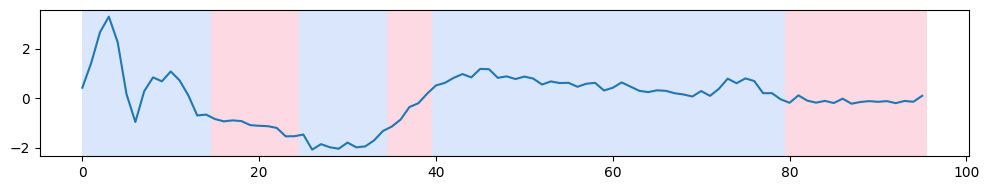

In [19]:
rpt.display(sample, result)
plt.show()